In [3]:
from pathlib import Path
import json
from statistics import mean
from typing import Any

import pandas as pd

In [4]:
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

In [5]:
EVALUATION_DIR = Path("backend/packages/schema_generator_agent/outputs/evaluation/llama3.3")

## Loading data

In [6]:
data = []

for eval_path in EVALUATION_DIR.glob("**/*/evaluation.json"):
    with open(eval_path, "r") as f:
        eval_data = json.load(f)
    
    case_name = eval_path.parent.parent.name
    data.append({"model": eval_path.parent.name, "case": case_name, **eval_data})

In [7]:
df = pd.DataFrame(data)

In [8]:
import re

def parse_model_params(model_str):
    pattern = r'maxrr_(\d+)_minrr_(\d+)_maxdrr_(\d+)_mindrr_(\d+)_dane_(\d+)'
    match = re.match(pattern, model_str)
    if match:
        return {
            'maxrr': int(match.group(1)),
            'minrr': int(match.group(2)),
            'maxdrr': int(match.group(3)),
            'mindrr': int(match.group(4)),
            'dane': int(match.group(5))
        }
    return {}

params_df = df.model.apply(parse_model_params).apply(pd.Series)
df = pd.concat([df, params_df], axis=1)
df.head()

,model,case,state_path,case_dir,num_schemas,num_experts,evaluations,maxrr,minrr,maxdrr,mindrr,dane
0,maxrr_3_minrr_1_maxdrr_2_mindrr_2_dane_3,contracts,multirun/llama3.3/contracts/maxrr_3_minrr_1_ma...,schema_generator_agent/data/eval/contracts,5,3,"[{'schema_index': 0, 'num_fields': 11, 'expert...",3,1,2,2,3
1,maxrr_4_minrr_1_maxdrr_2_mindrr_2_dane_2,contracts,multirun/llama3.3/contracts/maxrr_4_minrr_1_ma...,schema_generator_agent/data/eval/contracts,5,3,"[{'schema_index': 0, 'num_fields': 11, 'expert...",4,1,2,2,2
2,maxrr_3_minrr_1_maxdrr_2_mindrr_1_dane_2,contracts,multirun/llama3.3/contracts/maxrr_3_minrr_1_ma...,schema_generator_agent/data/eval/contracts,5,3,"[{'schema_index': 0, 'num_fields': 11, 'expert...",3,1,2,1,2
3,maxrr_2_minrr_2_maxdrr_3_mindrr_1_dane_2,contracts,multirun/llama3.3/contracts/maxrr_2_minrr_2_ma...,schema_generator_agent/data/eval/contracts,7,3,"[{'schema_index': 0, 'num_fields': 11, 'expert...",2,2,3,1,2
4,maxrr_3_minrr_2_maxdrr_2_mindrr_2_dane_1,contracts,multirun/llama3.3/contracts/maxrr_3_minrr_2_ma...,schema_generator_agent/data/eval/contracts,6,3,"[{'schema_index': 0, 'num_fields': 11, 'expert...",3,2,2,2,1


In [9]:
def calculate_coverage(evaluation_data: dict[str, Any]) -> list[float]:
    schema_coverage = []
    for schema in evaluation_data:
        coverage = []
        for expert in schema["experts"]:
            coverage.append(expert["covered_questions"] / expert["total_questions"])
        schema_coverage.append(mean(coverage))
    return schema_coverage

df["coverage"] = df.evaluations.apply(calculate_coverage)
df["max_coverage"] = df.coverage.apply(max)
df["last_coverage"] = df.coverage.apply(lambda x: x[-1])


## Params analysis

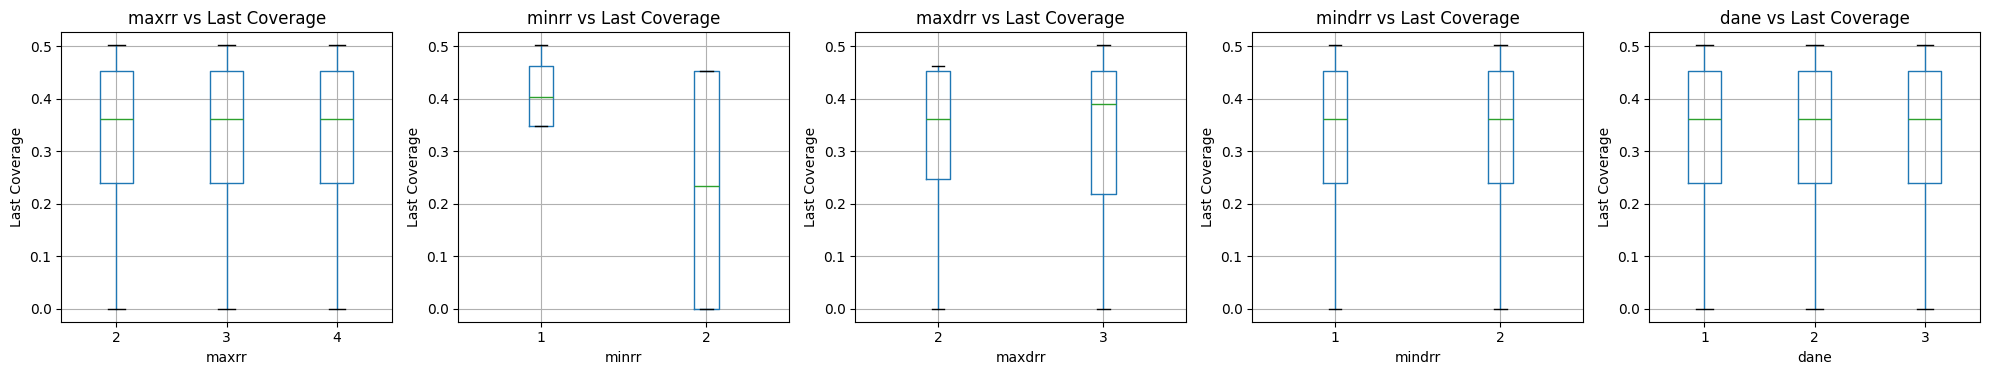

In [10]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
params = ['maxrr', 'minrr', 'maxdrr', 'mindrr', 'dane']

for idx, param in enumerate(params):
    df.boxplot(column='last_coverage', by=param, ax=axes[idx])
    axes[idx].set_title(f'{param} vs Last Coverage')
    axes[idx].set_xlabel(param)
    axes[idx].set_ylabel('Last Coverage')
    
plt.suptitle('')
plt.tight_layout()
plt.show()

In [16]:
rankings = []
for case in df['case'].unique():
    case_df = df[df['case'] == case].copy()
    case_df['rank'] = case_df['last_coverage'].rank(ascending=False, method='min')
    rankings.append(case_df[['model', 'case', 'rank']])

rankings_df = pd.concat(rankings)
avg_rankings = rankings_df.groupby('model')['rank'].mean().sort_values()

print("Average Rankings:")
print(avg_rankings)

best_rank = avg_rankings.min()
top_models = avg_rankings[avg_rankings == best_rank]

print(f"\nParameter sets tied for 1st place (avg rank: {best_rank:.2f}):")
for model in top_models.index:
    print(f"  {model}")

Average Rankings:
model
maxrr_2_minrr_1_maxdrr_3_mindrr_1_dane_1    13.0
maxrr_2_minrr_1_maxdrr_3_mindrr_1_dane_2    13.0
maxrr_2_minrr_1_maxdrr_3_mindrr_2_dane_1    13.0
maxrr_2_minrr_1_maxdrr_3_mindrr_1_dane_3    13.0
maxrr_2_minrr_1_maxdrr_3_mindrr_2_dane_3    13.0
                                            ... 
maxrr_4_minrr_2_maxdrr_3_mindrr_1_dane_2    31.0
maxrr_4_minrr_2_maxdrr_3_mindrr_1_dane_3    31.0
maxrr_4_minrr_2_maxdrr_3_mindrr_2_dane_1    31.0
maxrr_4_minrr_2_maxdrr_3_mindrr_2_dane_2    31.0
maxrr_4_minrr_2_maxdrr_3_mindrr_2_dane_3    31.0
Name: rank, Length: 72, dtype: float64

Parameter sets tied for 1st place (avg rank: 13.00):
  maxrr_2_minrr_1_maxdrr_3_mindrr_1_dane_1
  maxrr_2_minrr_1_maxdrr_3_mindrr_1_dane_2
  maxrr_2_minrr_1_maxdrr_3_mindrr_2_dane_1
  maxrr_2_minrr_1_maxdrr_3_mindrr_1_dane_3
  maxrr_2_minrr_1_maxdrr_3_mindrr_2_dane_3
  maxrr_2_minrr_1_maxdrr_3_mindrr_2_dane_2
  maxrr_3_minrr_1_maxdrr_3_mindrr_1_dane_1
  maxrr_3_minrr_1_maxdrr_3_mindrr_1_dane_2


In [12]:
best_model = "maxrr_4_minrr_1_maxdrr_3_mindrr_1_dane_3"

## Plotting Coverage

In [13]:
best_model_df = df[df['model'] == best_model]

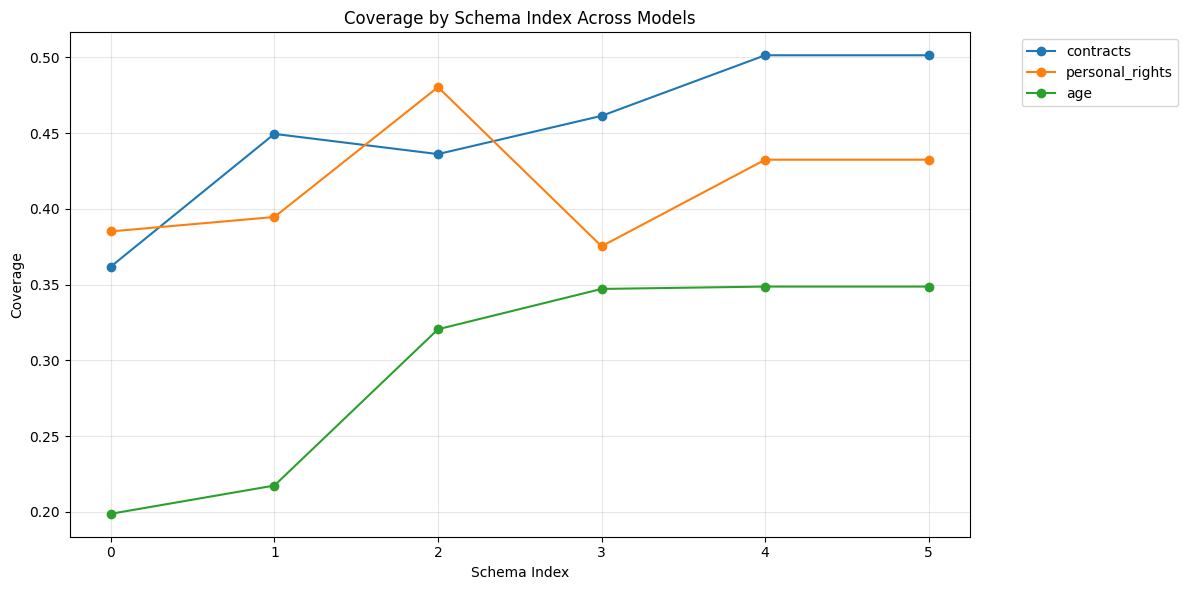

In [15]:
fig, ax = plt.subplots(figsize=(12, 6))

for idx, row in best_model_df.iterrows():
    schema_indices = list(range(len(row['coverage'])))
    ax.plot(schema_indices, row['coverage'], marker='o', label=row['case'])

ax.set_xlabel('Schema Index')
ax.set_ylabel('Coverage')
ax.set_title('Coverage by Schema Index Across Models')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()